# Residual Structure Comparison

This notebook checks whether newer models reduce the structured residual patterns identified after the Chapman-Richards baseline. It is deliberately read-only: it loads existing predictions and data, displays diagnostics, and does not write figures or modify model code.

Core question: if the statistical/spatial analysis found structure in Chapman-Richards residuals, do the DNN/PINN residuals still contain the same structure?

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "outputs").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing outputs/ and data/.")

ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
ROOT

PosixPath('/Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss')

## Configuration

Start with the primary dissertation cell: `4survey` + `spatial_block`. Change `COHORT` and `SPLIT_TYPE` below if you want to repeat the same diagnostics for `6survey`, `temporal`, or `temporal_narrow_gap`.

In [2]:
COHORT = "4survey"
SPLIT_TYPE = "spatial_block"

MODEL_RUNS = {
    "CR": "chapman_richards",
    "DNN no-env": "dnn_noenv",
    "PINN no-env w1": "pinn_noenv_basecase_w1",
    "DNN env-terrain": "dnn_env_terrain",
    "PINN env-terrain": "pinn_env_terrain",
    "Linear": "linear_baseline",
    "RF": "rf_baseline",
    "Average by age": "average_by_age",
}

CORE_MODELS = ["CR", "DNN no-env", "PINN no-env w1", "DNN env-terrain", "PINN env-terrain"]
TEST_ONLY = True

print(f"Diagnostics for {COHORT}, {SPLIT_TYPE}")

Diagnostics for 4survey, spatial_block


In [3]:
def prediction_path(model_dir, cohort=COHORT, split_type=SPLIT_TYPE):
    return ROOT / "outputs" / split_type / model_dir / cohort / "predictions.csv"

def load_predictions(model_label, model_dir):
    path = prediction_path(model_dir)
    if not path.exists():
        warnings.warn(f"Missing predictions for {model_label}: {path}")
        return None
    df = pd.read_csv(path)
    if TEST_ONLY and "split" in df.columns:
        df = df[df["split"] == "test"].copy()
    required = {"identification", "LiDAR_year", "Age", "observed_top_height", "predicted_top_height", "residual"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")
    df["model"] = model_label
    df["model_dir"] = model_dir
    return df

prediction_frames = []
for label, model_dir in MODEL_RUNS.items():
    loaded = load_predictions(label, model_dir)
    if loaded is not None:
        prediction_frames.append(loaded)

predictions = pd.concat(prediction_frames, ignore_index=True)
print(predictions.shape)
predictions.head()

(375744, 12)


,identification,blk,cpmt,LiDAR_year,Age,observed_top_height,predicted_top_height,residual,split,model,model_dir,learned_y_max
0,14684,31,2056,2008,26,9.227193,14.584379,-5.357186,test,CR,chapman_richards,NaN
1,14684,31,2056,2012,30,8.773904,16.258305,-7.484401,test,CR,chapman_richards,NaN
2,14684,31,2056,2021,39,9.103401,19.708078,-10.604677,test,CR,chapman_richards,NaN
3,14684,31,2056,2023,41,9.564199,20.421169,-10.856970,test,CR,chapman_richards,NaN
4,14687,31,2056,2008,26,10.072270,14.584379,-4.512109,test,CR,chapman_richards,NaN


## Overall Prediction Metrics

This is the ordinary accuracy comparison. It does not yet answer whether the models removed the same residual structure as the statistical analysis, but it gives the baseline context.

In [4]:
def metrics_for_group(df):
    observed = df["observed_top_height"].to_numpy(dtype=float)
    predicted = df["predicted_top_height"].to_numpy(dtype=float)
    residual = observed - predicted
    sse = np.sum(residual ** 2)
    sst = np.sum((observed - observed.mean()) ** 2)
    return pd.Series({
        "n_rows": len(df),
        "n_plots": df["identification"].nunique(),
        "mae": np.mean(np.abs(residual)),
        "rmse": np.sqrt(np.mean(residual ** 2)),
        "r2": 1 - sse / sst,
        "bias": residual.mean(),
        "residual_sd": residual.std(ddof=1),
    })

metrics = predictions.groupby("model", sort=False).apply(metrics_for_group).sort_values("rmse")
metrics

,n_rows,n_plots,mae,rmse,r2,bias,residual_sd
model,,,,,,,
DNN no-env,46972.0,11743.0,3.497814,4.655366,0.633024,0.397426,4.638421
DNN env-terrain,46956.0,11739.0,3.506825,4.707503,0.624718,-0.285271,4.698902
PINN env-terrain,46956.0,11739.0,3.792039,4.966583,0.582273,0.656922,4.922999
PINN no-env w1,46972.0,11743.0,3.823574,4.981450,0.579815,0.508945,4.955436
Linear,46972.0,11743.0,4.252696,5.370452,0.511628,0.348440,5.359193
RF,46972.0,11743.0,4.199335,5.569450,0.474765,-0.035254,5.569398
CR,46972.0,11743.0,4.734991,5.929715,0.404616,1.754273,5.664338
Average by age,46972.0,11743.0,4.957496,6.148120,0.359950,2.086224,5.783404


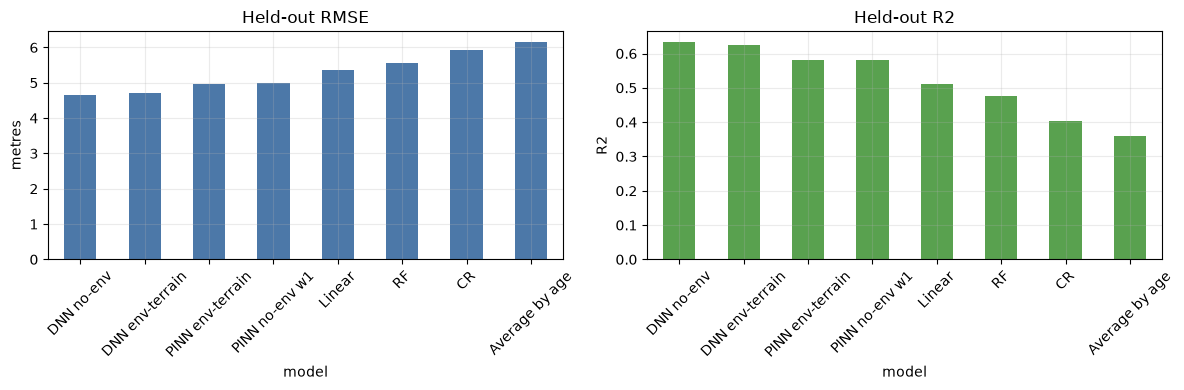

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metrics["rmse"].sort_values().plot.bar(ax=axes[0], color="#4c78a8")
axes[0].set_title("Held-out RMSE")
axes[0].set_ylabel("metres")
metrics["r2"].sort_values(ascending=False).plot.bar(ax=axes[1], color="#59a14f")
axes[1].set_title("Held-out R2")
axes[1].set_ylabel("R2")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

## Residual Distributions

If a model absorbs the structure left by Chapman-Richards, its residuals should be narrower and less biased. Positive residual means observed height is higher than predicted height, so the model is under-predicting.

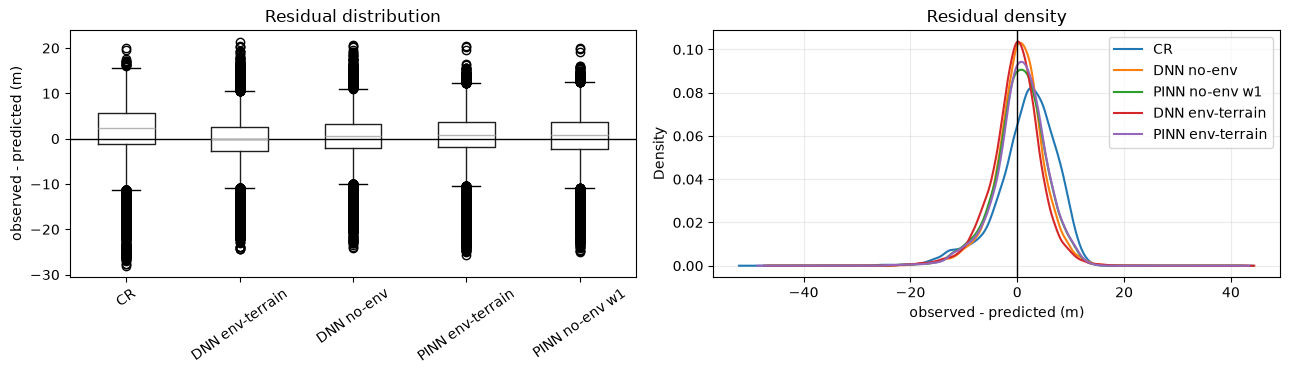

In [6]:
plot_df = predictions[predictions["model"].isin(CORE_MODELS)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_df.boxplot(column="residual", by="model", ax=axes[0], grid=False, rot=35)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residual distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("observed - predicted (m)")

for model, group in plot_df.groupby("model", sort=False):
    group["residual"].plot.kde(ax=axes[1], label=model)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Residual density")
axes[1].set_xlabel("observed - predicted (m)")
axes[1].legend()
plt.suptitle("")
plt.tight_layout()

## Age And Year Structure

These plots test whether the leftover errors are concentrated in particular stand ages or survey years. That matters because a model can have a decent RMSE while still missing a biologically important growth-stage pattern.

In [7]:
age_bins = [-np.inf, 30, 40, 60, 80, np.inf]
age_labels = ["<30", "30-40", "40-60", "60-80", "80+"]
plot_df["age_band"] = pd.cut(plot_df["Age"], bins=age_bins, labels=age_labels)

age_summary = (
    plot_df.groupby(["model", "age_band"], observed=True)
    .agg(n=("residual", "size"), bias=("residual", "mean"), mae=("residual", lambda x: np.mean(np.abs(x))), rmse=("residual", lambda x: np.sqrt(np.mean(x ** 2))))
    .reset_index()
)
age_summary

,model,age_band,n,bias,mae,rmse
0,CR,<30,13720,0.732355,2.654058,3.309300
1,CR,30-40,15861,2.883190,5.014244,5.853330
2,CR,40-60,11692,2.204597,6.249953,7.365824
3,CR,60-80,4433,0.839228,5.807031,7.324198
4,CR,80+,1266,-2.269281,6.042944,8.231172
5,DNN env-terrain,<30,13720,-0.329515,2.506693,3.225253
6,DNN env-terrain,30-40,15861,-0.656693,3.114328,4.042570
7,DNN env-terrain,40-60,11684,-0.385743,4.092990,5.366724
8,DNN env-terrain,60-80,4428,1.517158,5.856177,7.264909
9,DNN env-terrain,80+,1263,-0.529994,5.641062,7.360357


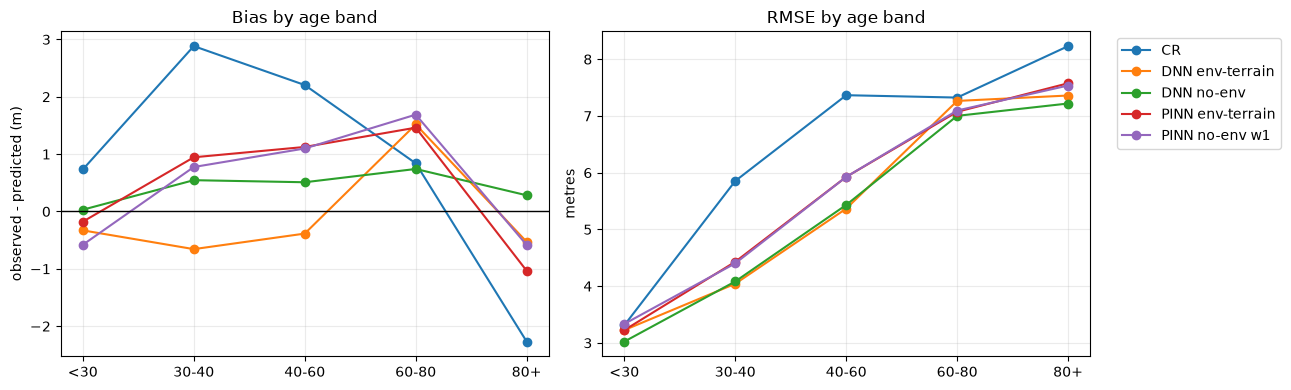

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model, group in age_summary.groupby("model", sort=False):
    axes[0].plot(group["age_band"].astype(str), group["bias"], marker="o", label=model)
    axes[1].plot(group["age_band"].astype(str), group["rmse"], marker="o", label=model)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Bias by age band")
axes[0].set_ylabel("observed - predicted (m)")
axes[1].set_title("RMSE by age band")
axes[1].set_ylabel("metres")
axes[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()

,model,LiDAR_year,n,bias,rmse
0,CR,2008,11743,0.127322,4.451459
1,CR,2012,11743,1.030126,5.193275
2,CR,2021,11743,2.521774,6.507516
3,CR,2023,11743,3.337871,7.177236
4,DNN env-terrain,2008,11739,-0.436713,3.950468
5,DNN env-terrain,2012,11739,-0.470629,4.555760
6,DNN env-terrain,2021,11739,-0.464096,4.973041
7,DNN env-terrain,2023,11739,0.230354,5.248816
8,DNN no-env,2008,11743,0.093467,3.786650
9,DNN no-env,2012,11743,0.118086,4.340963


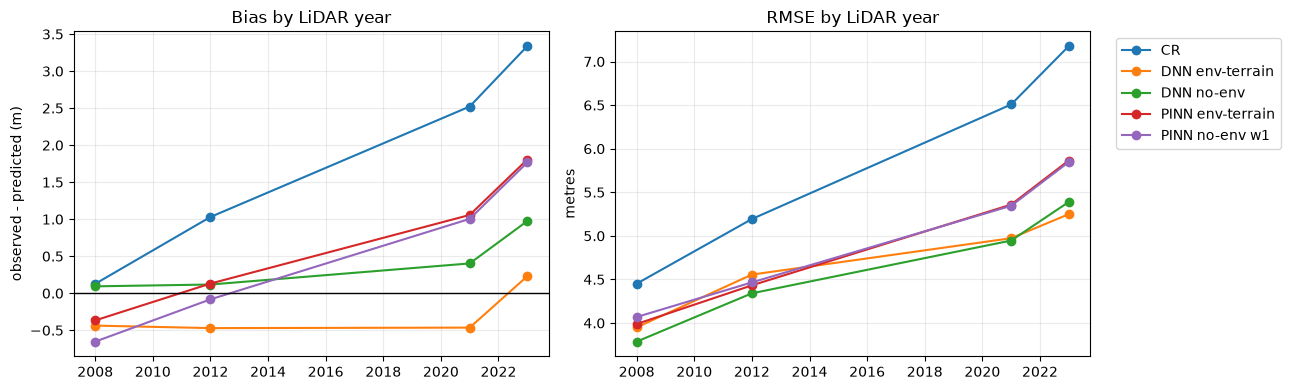

In [9]:
year_summary = (
    plot_df.groupby(["model", "LiDAR_year"])
    .agg(n=("residual", "size"), bias=("residual", "mean"), rmse=("residual", lambda x: np.sqrt(np.mean(x ** 2))))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model, group in year_summary.groupby("model", sort=False):
    axes[0].plot(group["LiDAR_year"], group["bias"], marker="o", label=model)
    axes[1].plot(group["LiDAR_year"], group["rmse"], marker="o", label=model)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Bias by LiDAR year")
axes[0].set_ylabel("observed - predicted (m)")
axes[1].set_title("RMSE by LiDAR year")
axes[1].set_ylabel("metres")
axes[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()

year_summary

## Compartment-Level Bias

Spatial block testing holds out whole areas, so compartment-level residual means are a useful way to see whether a model is still systematically too high/low in particular forest compartments.

In [10]:
cpmt_summary = (
    plot_df.groupby(["model", "cpmt"])
    .agg(n=("residual", "size"), bias=("residual", "mean"), rmse=("residual", lambda x: np.sqrt(np.mean(x ** 2))))
    .reset_index()
)

cpmt_spread = (
    cpmt_summary.groupby("model")
    .agg(n_compartments=("cpmt", "nunique"), mean_abs_cpmt_bias=("bias", lambda x: np.mean(np.abs(x))), max_abs_cpmt_bias=("bias", lambda x: np.max(np.abs(x))))
    .sort_values("mean_abs_cpmt_bias")
)
cpmt_spread

,n_compartments,mean_abs_cpmt_bias,max_abs_cpmt_bias
model,,,
DNN env-terrain,51,2.894074,10.490663
DNN no-env,51,2.932937,7.979750
PINN no-env w1,51,3.386965,10.638840
PINN env-terrain,51,3.426343,10.737503
CR,51,4.296497,15.833689


model,CR,DNN env-terrain,DNN no-env,PINN env-terrain,PINN no-env w1
cpmt,,,,,
2069,-15.833689,-9.183439,-7.797420,-10.737503,-10.638840
1105,-13.481729,-8.473110,-6.253606,-10.690064,-10.527917
2070,-12.862190,-8.184799,-7.001232,-8.669977,-8.644001
2094,-11.230138,-4.057524,-7.979750,-9.125177,-9.364391
1120,-8.686160,-7.062871,-7.278663,-7.838969,-7.617509
2056,-8.578102,-2.709912,-0.260738,-2.848399,-3.040606
2111,-8.015064,-3.313427,-5.375073,-5.376874,-5.422647
1095,7.769518,3.445545,2.985880,3.265348,3.183164
2185,6.027293,0.797796,1.349065,1.630225,1.582608


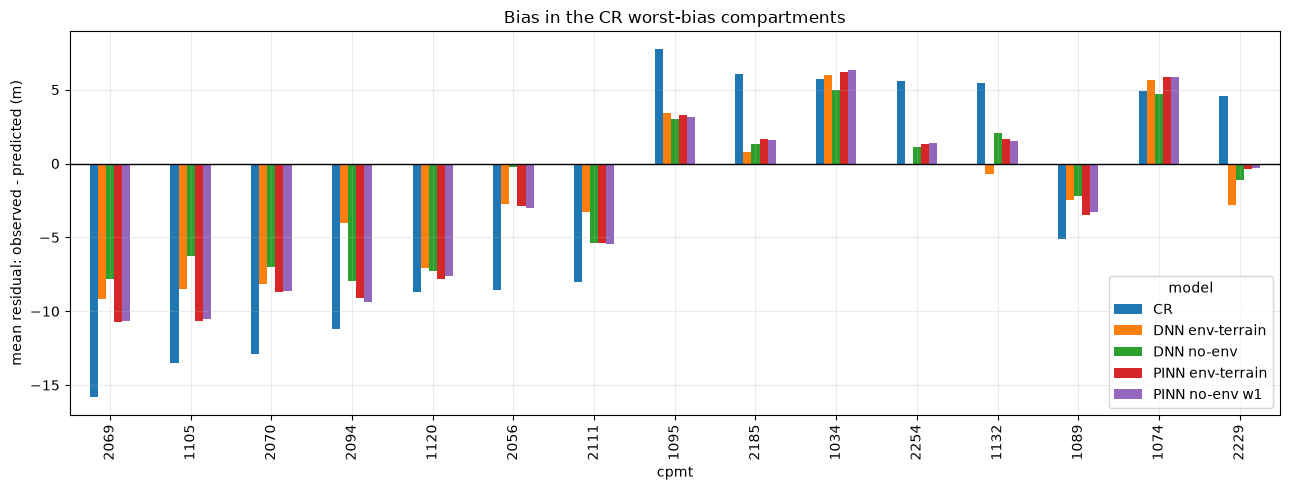

In [11]:
reference_model = "CR"
top_compartments = (
    cpmt_summary[cpmt_summary["model"] == reference_model]
    .assign(abs_bias=lambda d: d["bias"].abs())
    .sort_values("abs_bias", ascending=False)
    .head(15)["cpmt"]
)

top_cpmt = cpmt_summary[cpmt_summary["cpmt"].isin(top_compartments)].copy()
pivot = top_cpmt.pivot(index="cpmt", columns="model", values="bias").loc[top_compartments]
pivot.plot.bar(figsize=(13, 5))
plt.axhline(0, color="black", linewidth=1)
plt.title(f"Bias in the {reference_model} worst-bias compartments")
plt.ylabel("mean residual: observed - predicted (m)")
plt.tight_layout()

pivot

## Join Residuals To Coordinates And Environmental Variables

For spatial and environmental diagnostics, use one row per plot per model: the mean held-out residual across that plot's test years. This avoids treating repeated survey years from the same plot as independent spatial samples.

In [12]:
plot_residuals = (
    plot_df.groupby(["model", "identification", "cpmt"], as_index=False)
    .agg(
        mean_residual=("residual", "mean"),
        mean_abs_residual=("residual", lambda x: np.mean(np.abs(x))),
        n_years=("LiDAR_year", "nunique"),
        mean_age=("Age", "mean"),
        mean_observed_height=("observed_top_height", "mean"),
    )
)

env_path = ROOT / "data" / "processed" / "environmental" / "plot_environmental_features.parquet"
coords_path = ROOT / "data" / "interim" / "plot_coordinates.csv.gz"
env = pd.read_parquet(env_path)
coords = pd.read_csv(coords_path)

join_cols = ["identification", "cpmt"]
env_unique = env.drop_duplicates("identification")
coords_unique = coords.drop_duplicates("identification")

residual_env = plot_residuals.merge(coords_unique, on=join_cols, how="left", suffixes=("", "_coord"))
env_extra_cols = [c for c in env_unique.columns if c not in residual_env.columns or c in ["identification", "cpmt"]]
residual_env = residual_env.merge(env_unique[env_extra_cols], on=join_cols, how="left")

print(residual_env.shape)
residual_env.head()

(58707, 69)


,model,identification,cpmt,mean_residual,mean_abs_residual,n_years,mean_age,mean_observed_height,x,y,mean_cr_residual_4survey,mean_cr_residual_6survey,groundfrost_mean_4survey,groundfrost_mean_6survey,rainfall_mean_4survey,rainfall_mean_6survey,sfcWind_mean_4survey,sfcWind_mean_6survey,sun_mean_4survey,sun_mean_6survey,tas_mean_4survey,tas_mean_6survey,tasmax_mean_4survey,tasmax_mean_6survey,tasmin_mean_4survey,tasmin_mean_6survey,era5_land_temp_k,ceh_pedotope,ceh_twi,ceh_subsurface_drainage,ceh_textural_composition,soilgrids_ph,chelsa_bio1_celsius,chelsa_gdd5_degc,chelsa_bio12_precip_mm,gwa_wind_speed_10m,dist_to_cpmt_boundary,dist_to_forest_perimeter,scpt,blk,dist_to_scpt_boundary,dist_to_block_boundary,cpmt_compactness_ratio,elevation_roughness,neighbour_mean_height,neighbour_height_differential,slope_degrees,aspect_degrees,profile_curvature,plan_curvature,tpi,frost_hollow_flag,solar_radiation_index,inverse_slope_proxy,dist_to_watercourse,dist_to_road,topex,elevation,windward_topex,northness,eastness,whcl,Age,CanopyCover,Thin,time_since_thinning,time_since_thinning_missing,recent_thinning_5yr,yldc
0,CR,14684,2056,-8.575808,8.575808,4,34.0,9.167174,242115.406,704028.4975,-8.817584,NaN,8.927716,8.775445,186.691537,197.347164,3.452893,3.523292,101.385696,99.210691,8.988315,9.074582,12.695123,12.755081,5.253881,5.376972,272.766499,10.0,7.021230,1.0,4.0,4.4,8.05,1296.0,2424.9,1.541,49.241834,49.241834,A,31,62.019586,38.737590,0.021488,31.932692,7.336059,2.228140,23.223392,80.340107,-0.000429,-0.001647,-3.200,0.0,0.737485,-23.223392,571.564773,411.222003,-8.715328,244.0,2.159028,0.167799,0.985821,4,34.0,0.195229,0.0,0.0,1.0,0.0,12
1,CR,14687,2056,-11.621195,11.621195,4,34.0,6.121788,242175.406,704028.4975,-11.862971,NaN,8.927716,8.775445,186.691537,197.347164,3.452893,3.523292,101.385696,99.210691,8.988315,9.074582,12.695123,12.755081,5.253881,5.376972,272.766499,11.0,7.416276,1.0,4.0,4.4,8.05,1296.0,2424.9,1.541,31.622777,99.146662,A,31,44.606813,31.622777,0.021488,26.761583,12.087545,-5.699401,21.164226,65.752011,-0.000716,-0.003272,-6.336,1.0,0.704536,-21.164226,518.204691,362.099234,-0.343905,224.1,3.861607,0.410687,0.911776,4,34.0,0.107041,0.0,0.0,1.0,0.0,12
2,CR,14693,2056,-11.766196,11.766196,4,34.0,5.976786,242175.406,704048.4975,-12.007972,NaN,8.927716,8.775445,186.691537,197.347164,3.452893,3.523292,101.385696,99.210691,8.988315,9.074582,12.695123,12.755081,5.253881,5.376972,272.766499,11.0,7.416276,1.0,4.0,4.4,8.05,1296.0,2424.9,1.541,14.142136,110.249756,A,31,37.454110,14.142136,0.021488,26.761583,14.471503,-7.270119,21.164226,65.752011,-0.000716,-0.003272,-6.336,1.0,0.704536,-21.164226,508.998980,350.231003,-0.343905,224.1,3.861607,0.410687,0.911776,4,34.0,0.129532,0.0,0.0,1.0,0.0,12
3,CR,14699,2056,-11.778214,11.778214,4,34.0,5.964768,242155.406,704068.4975,-12.019990,NaN,8.927716,8.775445,186.691537,197.347164,3.452893,3.523292,101.385696,99.210691,8.988315,9.074582,12.695123,12.755081,5.253881,5.376972,272.766499,11.0,7.156669,1.0,4.0,4.4,8.05,1296.0,2424.9,1.541,30.000000,104.717906,A,31,37.607196,30.000000,0.021488,29.762318,10.219762,-2.668800,25.235761,65.827683,-0.000885,-0.001898,-6.304,1.0,0.666772,-25.235761,517.813026,356.188455,4.987611,215.0,5.778659,0.409482,0.912318,4,34.0,0.147598,0.0,0.0,1.0,0.0,12
4,CR,14710,2056,-4.981556,4.981556,4,34.0,12.761426,242115.406,704108.4975,-5.223332,NaN,8.927716,8.775445,186.691537,197.347164,3.452893,3.523292,101.385696,99.210691,8.988315,9.074582,12.695123,12.755081,5.253881,5.376972,272.766499,10.0,5.679075,1.0,4.0,4.4,8.05,1296.0,2424.9,1.541,37.876671,93.654208,A,31,37.913366,37.876671,0.021488,35.632135,9.868493,2.954358,29.083267,73.389556,0.001272,0.003405,8.988,0.0,0.660238,-29.083267,535.441119,368.533274,-1.527459,237.9,5.489268,0.285863,0.958270,4,34.0,0.396103,0.0,0.0,1.0,0.0,12


## Spatial Residual Maps

These maps are visual diagnostics only. Look for whether the same high/low residual zones visible in the Chapman-Richards map remain in the DNN/PINN maps.

/var/folders/x0/2y372y254qxd8j967dgmwpr00000gn/T/ipykernel_52024/545435188.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


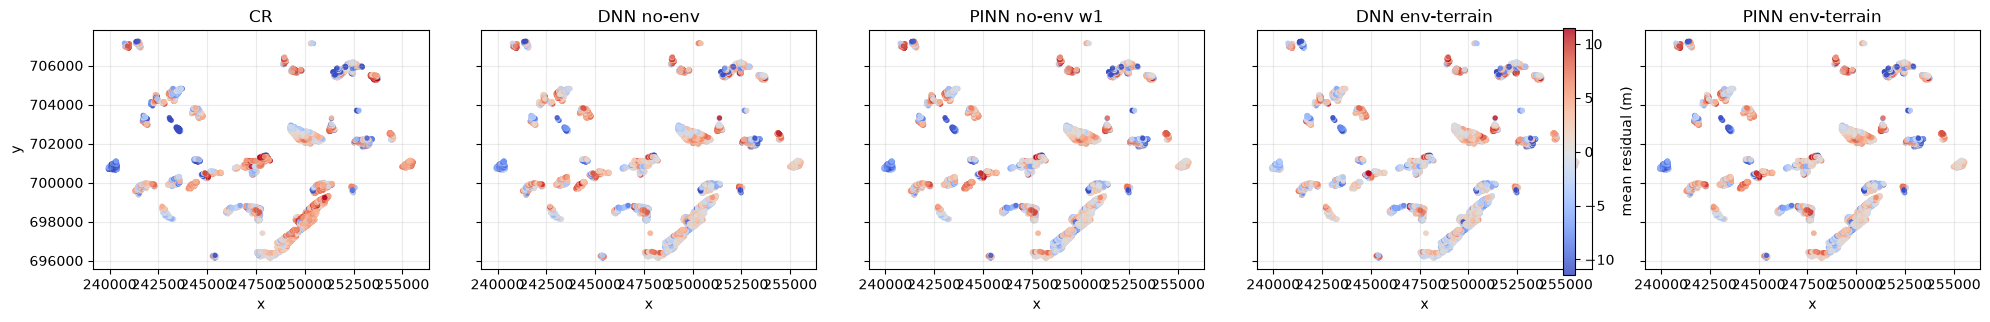

In [13]:
map_models = [m for m in CORE_MODELS if m in residual_env["model"].unique()]
vmax = np.nanpercentile(np.abs(residual_env[residual_env["model"].isin(map_models)]["mean_residual"]), 98)

fig, axes = plt.subplots(1, len(map_models), figsize=(4 * len(map_models), 4), sharex=True, sharey=True)
if len(map_models) == 1:
    axes = [axes]
for ax, model in zip(axes, map_models):
    sub = residual_env[residual_env["model"] == model].dropna(subset=["x", "y"])
    sc = ax.scatter(sub["x"], sub["y"], c=sub["mean_residual"], cmap="coolwarm", vmin=-vmax, vmax=vmax, s=8, alpha=0.85)
    ax.set_title(model)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(sc, ax=axes, shrink=0.8, label="mean residual (m)")
plt.tight_layout()

## Spatial Autocorrelation

This estimates the spatial range with a semivariogram and then calculates Moran's I at that distance. If the DNN/PINN has absorbed the spatial structure in the CR residuals, Moran's I should fall. If it stays high, important spatial structure remains unexplained.

If `esda` or `libpysal` are not installed, this cell will report that and skip Moran's I rather than failing the notebook.

In [ ]:
try:
    from models.spatial_attribution.spatial_autocorrelation import semivariogram_range, global_morans_i
    spatial_rows = []
    for model in map_models:
        sub = residual_env[residual_env["model"] == model].dropna(subset=["x", "y", "mean_residual"])
        if len(sub) < 50:
            spatial_rows.append({"model": model, "n": len(sub), "range_m": np.nan, "range_status": "too_few_points", "morans_i": np.nan, "p_sim": np.nan})
            continue
        range_m, status = semivariogram_range(sub["x"], sub["y"], sub["mean_residual"], max_distance=5000, n_bins=15, sample_size=5000)
        if np.isfinite(range_m) and range_m > 0:
            morans_i, p_sim = global_morans_i(sub["x"], sub["y"], sub["mean_residual"], distance=range_m, sample_size=5000, permutations=999)
        else:
            morans_i, p_sim = np.nan, np.nan
        spatial_rows.append({"model": model, "n": len(sub), "range_m": range_m, "range_status": status, "morans_i": morans_i, "p_sim": p_sim})
    spatial_summary = pd.DataFrame(spatial_rows).sort_values("morans_i", na_position="last")
except Exception as exc:
    spatial_summary = pd.DataFrame({"message": [f"Spatial autocorrelation skipped: {type(exc).__name__}: {exc}"]})

spatial_summary

## Can Environmental/Site Variables Still Predict The Leftover Residuals?

This is the most direct bridge to the statistical residual analysis. For each model, fit a small secondary model to predict that model's held-out residuals from environmental/site variables. Lower secondary-model R2 means less environmental/site structure remains in the residuals.

Interpretation:

- High R2 for CR residuals: Chapman-Richards left environmental/site structure unexplained.
- Lower R2 for DNN/PINN residuals: that model absorbed some of the structure.
- Similar or higher R2 after DNN/PINN: the model did not capture that structure, even if its RMSE improved.

The feature list deliberately excludes observed height and mean age. Those variables are too close to the prediction target/residual definition and would make the diagnostic look stronger than it really is.

In [ ]:
candidate_feature_cols = [
    "ceh_twi", "eastness", "elevation", "northness", "topex",
    "whcl", "plan_curvature", "profile_curvature", "slope_degrees", "aspect_degrees", "tpi",
    "chelsa_bio1_celsius", "chelsa_bio12_precip_mm", "chelsa_gdd5_degc", "soilgrids_ph",
    "dist_to_watercourse", "dist_to_road", "dist_to_cpmt_boundary", "dist_to_forest_perimeter",
    "gwa_wind_speed_10m", "windward_topex", "elevation_roughness", "frost_hollow_flag",
    "CanopyCover", "Thin", "recent_thinning_5yr", "time_since_thinning", "yldc",
]
feature_cols = [c for c in candidate_feature_cols if c in residual_env.columns]
feature_cols

In [ ]:
def residual_predictability_for_model(df, model, feature_cols, estimator_name="ridge"):
    sub = df[df["model"] == model].dropna(subset=["mean_residual"]).copy()
    X = sub[feature_cols]
    y = sub["mean_residual"].to_numpy(dtype=float)
    if len(sub) < 100:
        return {"model": model, "estimator": estimator_name, "n": len(sub), "cv_r2": np.nan, "cv_mae": np.nan, "note": "too_few_rows"}

    if estimator_name == "ridge":
        estimator = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", RidgeCV(alphas=np.logspace(-3, 3, 13))),
        ])
    elif estimator_name == "rf":
        estimator = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1)),
        ])
    else:
        raise ValueError(estimator_name)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    pred = cross_val_predict(estimator, X, y, cv=cv, n_jobs=None)
    return {
        "model": model,
        "estimator": estimator_name,
        "n": len(sub),
        "cv_r2": r2_score(y, pred),
        "cv_mae": mean_absolute_error(y, pred),
        "residual_sd": np.std(y, ddof=1),
        "note": "",
    }

predictability_rows = []
for model in map_models:
    for estimator_name in ["ridge", "rf"]:
        predictability_rows.append(residual_predictability_for_model(residual_env, model, feature_cols, estimator_name=estimator_name))

predictability = pd.DataFrame(predictability_rows).sort_values(["estimator", "cv_r2"], ascending=[True, False])
predictability

In [ ]:
pivot_pred = predictability.pivot(index="model", columns="estimator", values="cv_r2").reindex(map_models)
pivot_pred.plot.bar(figsize=(10, 4), color=["#4c78a8", "#f58518"])
plt.axhline(0, color="black", linewidth=1)
plt.title("How predictable are leftover residuals from environment/site variables?")
plt.ylabel("cross-validated R2 on model residuals")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
pivot_pred

## Reading The Results

Use this checklist when interpreting the notebook:

1. Does RMSE improve relative to Chapman-Richards?
2. Does the residual distribution narrow and centre near zero?
3. Do age/year bias curves flatten?
4. Do compartment biases shrink?
5. Does spatial autocorrelation fall relative to CR residuals?
6. Are the leftover residuals less predictable from environmental/site variables?

A model that improves RMSE but leaves the same spatial/environmental residual signal has improved prediction but has not explained the process found by the statistical residual analysis. A model that reduces Moran's I or residual predictability has stronger evidence that it captured the structured residual process.